In [1]:
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error


In [2]:
import matplotlib.pyplot as plt


In [3]:
data1 = pd.read_csv('Sales2.csv')

In [4]:
data1['Date'] = pd.to_datetime(data1['Date'])

In [5]:
#sumsale_by_product
data1 = data1.groupby(['Date','Item Purchased'])['Sales'].sum()
# Chuyển Series thành DataFrame
data1 = pd.DataFrame(data1, columns=['Sales'])
# new_data_df
data1.head(20)

Sales
Date       Item Purchased       
2023-01-01 Skirt               2
2023-01-02 Blouse            134
           Dress              13
           Shirt              65
           Skirt               5
2023-01-03 Blouse             57
           Dress               6
2023-01-04 Blouse             92
           Dress               8
           Shirt              40
           Skirt               3
2023-01-05 Blouse             59
           Dress              42
           Shirt              21
2023-01-06 Blouse             50
           Dress              10
           Shirt              26
           Skirt               3
2023-01-08 Blouse            226
           Dress              24

In [6]:
#change index của dataframe
data1=data1.reset_index()
data1 = data1.set_index('Date')

In [7]:
true_item=['Shirt']
data1 = data1.loc[data1['Item Purchased'].isin(true_item)]
import copy
dataconcate=copy.copy(data1)

In [8]:
# Preprocess the data
scaler = MinMaxScaler()
data1['Sales'] = scaler.fit_transform(data1['Sales'].values.reshape(-1, 1))
data1.head(5)

,Item Purchased,Sales
Date,,
2023-01-02,Shirt,0.290909
2023-01-04,Shirt,0.177273
2023-01-05,Shirt,0.090909
2023-01-06,Shirt,0.113636
2023-01-08,Shirt,0.177273


In [9]:
# Split the data into training and testing sets
train_size = int(len(data1) * 0.7)
train_data, test_data = data1[:train_size], data1[train_size:]

In [10]:
# Create sequences for LSTM
def create_sequences(data1, sequence_length):
    sequences = []
    for i in range(len(data1) - sequence_length):
        sequence = data1[i:i+sequence_length]
        target = data1[i+sequence_length:i+sequence_length+1]
        sequences.append((sequence, target))
    return sequences

sequence_length = 10
train_sequences = create_sequences(train_data['Sales'], sequence_length)
test_sequences = create_sequences(test_data['Sales'], sequence_length)

X_train, y_train = np.array([seq[0] for seq in train_sequences]), np.array([seq[1] for seq in train_sequences])
X_test, y_test = np.array([seq[0] for seq in test_sequences]), np.array([seq[1] for seq in test_sequences])



In [11]:
# Build the LSTM model
import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense
model = Sequential()
model.add(LSTM(100, activation='relu', input_shape=(sequence_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

In [12]:
model.fit(X_train, y_train, epochs=50, batch_size=32)
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

Epoch 1/50
2/2 [==============================] - 4s 25ms/step - loss: 0.0113
Epoch 2/50
2/2 [==============================] - 0s 17ms/step - loss: 0.0089
Epoch 3/50
2/2 [==============================] - 0s 20ms/step - loss: 0.0074
Epoch 4/50
2/2 [==============================] - 0s 15ms/step - loss: 0.0063
Epoch 5/50
2/2 [==============================] - 0s 15ms/step - loss: 0.0056
Epoch 6/50
2/2 [==============================] - 0s 17ms/step - loss: 0.0054
Epoch 7/50
2/2 [==============================] - 0s 15ms/step - loss: 0.0057
Epoch 8/50
2/2 [==============================] - 0s 17ms/step - loss: 0.0058
Epoch 9/50
2/2 [==============================] - 0s 15ms/step - loss: 0.0057
Epoch 10/50
2/2 [==============================] - 0s 15ms/step - loss: 0.0056
Epoch 11/50
2/2 [==============================] - 0s 17ms/step - loss: 0.0054
Epoch 12/50
2/2 [==============================] - 0s 16ms/step - loss: 0.0054
Epoch 13/50
2/2 [==============================] - 0s 15ms/st

In [13]:
# Inverse transform the scaled predictions to get actual sales values
train_predictions = scaler.inverse_transform(train_predictions)
test_predictions = scaler.inverse_transform(test_predictions)

In [14]:
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train RMSE: 17.340209703521882
Test RMSE: 20.51480728201774


In [15]:
print(test_predictions)

[[15.247338]
 [22.244179]
 [22.726236]
 [41.221596]
 [34.09451 ]
 [28.706358]
 [23.307491]
 [19.55316 ]
 [15.943783]
 [13.231765]
 [10.765373]
 [ 8.993821]
 [ 8.649499]
 [ 8.908748]
 [ 8.91569 ]
 [ 9.265378]]


In [16]:
import tensorflow as tf
# Predict sales for future time steps
time_steps = sequence_length
future_time_steps = 60
future_data = data1['Sales'].values[-time_steps:].reshape(1, -1, 1)
future_data = future_data.reshape(1, time_steps, 1)
future_predictions = []

for _ in range(future_time_steps):
    next_prediction = model.predict(tf.convert_to_tensor(future_data))
    future_predictions.append(next_prediction[0, 0])
    future_data = np.append(future_data[:, 1:, :], next_prediction.reshape(1, 1, 1), axis=1)

# Inverse transform the future predictions
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Generate future timestamps
last_timestamp = data1.index[-1]
future_timestamps = pd.date_range(start=last_timestamp, periods=future_time_steps+1, freq=data1.index.freq)



1/1 [==============================] - 0s 52ms/step


In [17]:
print(future_predictions)

[[ 9.108792 ]
 [ 9.692935 ]
 [10.308487 ]
 [10.909766 ]
 [11.495942 ]
 [12.047274 ]
 [12.513906 ]
 [12.982598 ]
 [13.386112 ]
 [13.729492 ]
 [14.053474 ]
 [14.302188 ]
 [14.523883 ]
 [14.7186575]
 [14.88883  ]
 [15.036348 ]
 [15.164423 ]
 [15.27532  ]
 [15.37107  ]
 [15.452916 ]
 [15.523554 ]
 [15.584635 ]
 [15.637486 ]
 [15.682989 ]
 [15.722226 ]
 [15.756076 ]
 [15.785102 ]
 [15.809823 ]
 [15.831089 ]
 [15.8493805]
 [15.865106 ]
 [15.87862  ]
 [15.890228 ]
 [15.900203 ]
 [15.908768 ]
 [15.916116 ]
 [15.922418 ]
 [15.927831 ]
 [15.932482 ]
 [15.936475 ]
 [15.939901 ]
 [15.942842 ]
 [15.945371 ]
 [15.947539 ]
 [15.949398 ]
 [15.950999 ]
 [15.952372 ]
 [15.953551 ]
 [15.954561 ]
 [15.95543  ]
 [15.956174 ]
 [15.956817 ]
 [15.957366 ]
 [15.957838 ]
 [15.958244 ]
 [15.958591 ]
 [15.958887 ]
 [15.959147 ]
 [15.959364 ]
 [15.959558 ]]


In [18]:
future_timestamps=future_timestamps[1:]
future_timestamps

DatetimeIndex(['2023-04-28', '2023-04-29', '2023-04-30', '2023-05-01',
               '2023-05-02', '2023-05-03', '2023-05-04', '2023-05-05',
               '2023-05-06', '2023-05-07', '2023-05-08', '2023-05-09',
               '2023-05-10', '2023-05-11', '2023-05-12', '2023-05-13',
               '2023-05-14', '2023-05-15', '2023-05-16', '2023-05-17',
               '2023-05-18', '2023-05-19', '2023-05-20', '2023-05-21',
               '2023-05-22', '2023-05-23', '2023-05-24', '2023-05-25',
               '2023-05-26', '2023-05-27', '2023-05-28', '2023-05-29',
               '2023-05-30', '2023-05-31', '2023-06-01', '2023-06-02',
               '2023-06-03', '2023-06-04', '2023-06-05', '2023-06-06',
               '2023-06-07', '2023-06-08', '2023-06-09', '2023-06-10',
               '2023-06-11', '2023-06-12', '2023-06-13', '2023-06-14',
               '2023-06-15', '2023-06-16', '2023-06-17', '2023-06-18',
               '2023-06-19', '2023-06-20', '2023-06-21', '2023-06-22',
      

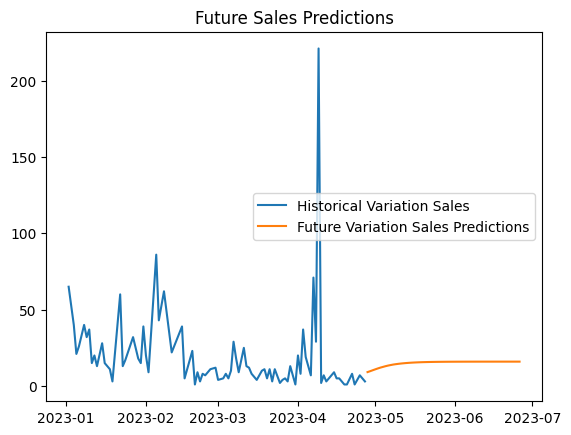

In [19]:
sale2nextmonth=pd.DataFrame(future_predictions,columns=['sale_prediction'], index=future_timestamps)
csv_file_path = 'predictsale2nextmonth_shirt.csv'
sale2nextmonth.to_csv(csv_file_path)

# Plot the results
plt.plot(data1.index, scaler.inverse_transform(data1['Sales'].values.reshape(-1, 1)), label='Historical Variation Sales')
plt.plot(future_timestamps, future_predictions, label='Future Variation Sales Predictions')
plt.legend()
plt.title('Future Sales Predictions')
plt.show()

In [20]:
print(sale2nextmonth)

            sale_prediction
2023-04-28         9.108792
2023-04-29         9.692935
2023-04-30        10.308487
2023-05-01        10.909766
2023-05-02        11.495942
2023-05-03        12.047274
2023-05-04        12.513906
2023-05-05        12.982598
2023-05-06        13.386112
2023-05-07        13.729492
2023-05-08        14.053474
2023-05-09        14.302188
2023-05-10        14.523883
2023-05-11        14.718657
2023-05-12        14.888830
2023-05-13        15.036348
2023-05-14        15.164423
2023-05-15        15.275320
2023-05-16        15.371070
2023-05-17        15.452916
2023-05-18        15.523554
2023-05-19        15.584635
2023-05-20        15.637486
2023-05-21        15.682989
2023-05-22        15.722226
2023-05-23        15.756076
2023-05-24        15.785102
2023-05-25        15.809823
2023-05-26        15.831089
2023-05-27        15.849380
2023-05-28        15.865106
2023-05-29        15.878620
2023-05-30        15.890228
2023-05-31        15.900203
2023-06-01        15

In [21]:
sale6month = pd.concat([dataconcate, sale2nextmonth],axis=1)
sale6month

,Item Purchased,Sales,sale_prediction
2023-01-02,Shirt,65.0,NaN
2023-01-04,Shirt,40.0,NaN
2023-01-05,Shirt,21.0,NaN
2023-01-06,Shirt,26.0,NaN
2023-01-08,Shirt,40.0,NaN
...,...,...,...
2023-06-22,NaN,NaN,15.958591
2023-06-23,NaN,NaN,15.958887
2023-06-24,NaN,NaN,15.959147
2023-06-25,NaN,NaN,15.959364


In [22]:
csv_file_path = 'sale6nextmonth_shirt.csv'
sale6month.to_csv(csv_file_path)

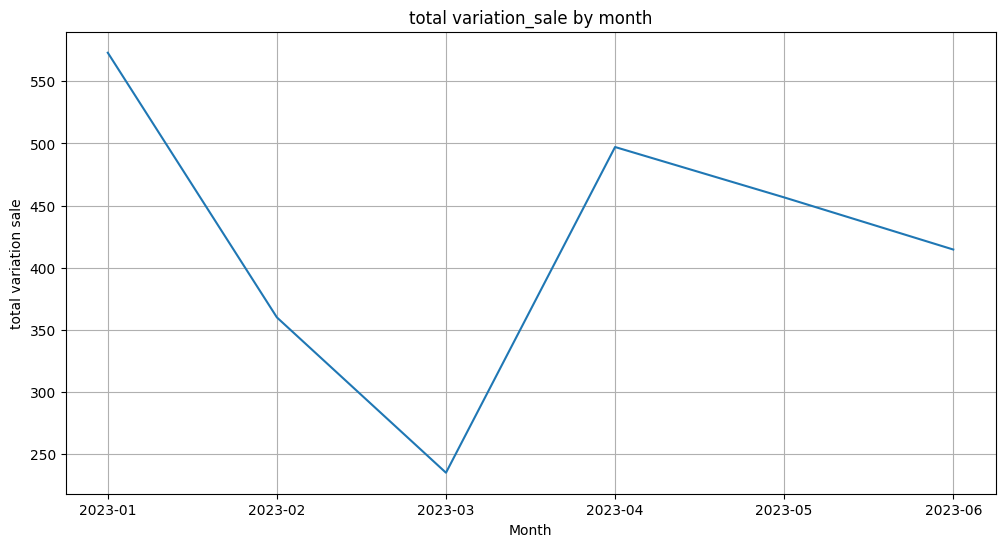

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sale6nextmonth_shirt.csv")
df = df.rename(columns={'Unnamed: 0': 'date'})

for index, row in df.iterrows():
    if pd.isna(df.at[index, "Sales"]):
        df.at[index, "Sales"] = row["sale_prediction"]

# Giả sử bạn có DataFrame 'df' với các cột 'date' và 'variation_sale'
# Cột 'date' có định dạng 'YYYY-MM-DD'

# Tính tổng variation_sale theo tháng
monthly_sales = df.groupby(pd.to_datetime(df['date']).dt.strftime('%Y-%m'))['Sales'].sum().reset_index()

# Đổi tên cột
monthly_sales = monthly_sales.rename(columns={'index': 'month', 'Sales': 'total_variation_sale'})

# Vẽ biểu đồ đường
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales["date"], monthly_sales['total_variation_sale'])
plt.title('total variation_sale by month')
plt.xlabel('Month')
plt.ylabel('total variation sale')
plt.grid()
plt.show()